# The Best Neighborhood in Pittsburgh
## Sub-Metric: Air Quality Index
### CMPINF 10/11 — Final Project (Individual Notebook)

---

## 1. Introduction

What makes a neighborhood the *best*? There are a lot of ways to answer that but one factor that tends to fly under the radar is the air you breathe every single day. Air quality has direct, measurable effects on human health: poor air is linked to asthma, cardiovascular disease, and even cognitive decline. For anyone who spends time outside, exercises, has kids, or simply wants to live a long healthy life, air quality is a genuine quality-of-life issue.

For my sub-metric, I'm arguing that the best neighborhood in Pittsburgh is the one with the cleanest, healthiest air. I'm operationalizing this using the Air Quality Index (AQI), a standardized government scale where lower numbers mean cleaner air and higher numbers mean worse air. An AQI below 50 is considered "Good," 51–100 is "Moderate," 101–150 is "Unhealthy for Sensitive Groups," and it only gets worse from there.

Pittsburgh has a well-documented history with air pollution — it was once the smog capital of the United States due to its steel industry. While things have improved dramatically, air quality still varies meaningfully across different parts of the city and surrounding area, particularly near industrial sites along the Mon Valley. This makes AQI a compelling and relevant sub-metric for our analysis.

My dataset spans a full decade of daily AQI readings (2016–2026), giving us a statistically robust picture of each monitoring site's long-term air quality rather than a snapshot.

---

## 2. The Metric

### Dataset

**Dataset:** Allegheny County Air Quality — Daily AQI Readings  
**Source:** Western Pennsylvania Regional Data Center (WPRDC)  
**Coverage:** January 1, 2016 – April 27, 2026  
**Size:** 83,639 readings across 15 monitoring sites  

Each row in the dataset represents a single pollutant reading at a specific monitoring station on a specific day. The columns are:

| Column | Description |
|---|---|
| `date` | Date of measurement |
| `site` | Name of monitoring station (proxy for neighborhood) |
| `parameter` | Pollutant measured (PM2.5, PM10, CO, SO2, NO2, Ozone) |
| `index_value` | AQI value for that reading |
| `description` | AQI category: Good, Moderate, Unhealthy, etc. |

### How I Calculate the Sub-Metric Score

For each monitoring site, I compute two values:

1. **Mean AQI** — the average `index_value` across all readings and all pollutants. Lower is better.
2. **% Good Days** — the percentage of readings that fall in the "Good" AQI category (≤ 50). Higher is better.

I then combine these into a single Air Quality Score by normalizing each metric to a 0–100 scale and taking the average. The site with the highest Air Quality Score has the cleanest air.

Why two metrics instead of one? Mean AQI alone can be skewed by a few extreme readings. Pairing it with % Good Days gives a fuller picture: a site with generally low AQI but occasional bad spikes will rank lower than a consistently clean site.

---

## 3. Analysis

### 3.1 Setup & Data Loading

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Load the dataset
df = pd.read_csv('air_quality.csv', parse_dates=['date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Monitoring sites: {df['site'].nunique()}")
df.head()

Dataset shape: (83639, 8)
Date range: 2016-01-01 to 2026-04-27
Monitoring sites: 15


,_id,date,site,parameter,index_value,description,health_advisory,health_effects
0,1,2016-01-01,Lawrenceville,PM25B,25,Good,NaN,NaN
1,2,2016-01-01,Flag Plaza,CO,0,Good,NaN,NaN
2,3,2016-01-01,Harrison Township,OZONE,31,Good,NaN,NaN
3,4,2016-01-01,Avalon,SO2,10,Good,NaN,NaN
4,5,2016-01-01,Lincoln,PM25,35,Good,NaN,NaN


### 3.2 Data Overview

In [5]:
# Quick summary statistics
print("AQI Description breakdown across all sites and years:")
print(df['description'].value_counts())
print()
print("Monitoring sites in the dataset:")
print(df['site'].unique())

AQI Description breakdown across all sites and years:
description
Good                              76264
Moderate                           7206
Unhealthy for Sensitive Groups      148
Unhealthy                            19
Very Unhealthy                        2
Name: count, dtype: int64

Monitoring sites in the dataset:
<StringArray>
[        'Lawrenceville',            'Flag Plaza',     'Harrison Township',
                'Avalon',               'Lincoln',         'South Fayette',
        'North Braddock',          'Parkway East',             'Liberty 2',
       'Lawrenceville 2', 'Glassport High Street',               'Liberty',
              'Clairton',          'West Mifflin',            'Pittsburgh']
Length: 15, dtype: str


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# health_advisory and health_effects are only filled in for non-Good readings
# Drop rows where index_value is missing
df = df.dropna(subset=['index_value', 'site'])
print(f"\nRows after cleaning: {len(df)}")

Missing values per column:
_id                    0
date                   0
site                   0
parameter              0
index_value            0
description            0
health_advisory    76561
health_effects     76561
dtype: int64

Rows after cleaning: 83639


### 3.3 Computing the Air Quality Score

In [7]:
# Mean AQI per site
mean_aqi = df.groupby('site')['index_value'].mean().rename('mean_aqi')

# % of readings classified as Good per site
good_pct = (
    df.groupby('site')
    .apply(lambda x: (x['description'] == 'Good').sum() / len(x) * 100)
    .rename('pct_good')
)

# Count of Unhealthy or worse readings per site
unhealthy_cats = ['Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
bad_counts = (
    df[df['description'].isin(unhealthy_cats)]
    .groupby('site').size()
    .rename('unhealthy_count')
)

# Combine into summary table
summary = pd.concat([mean_aqi, good_pct, bad_counts], axis=1).fillna(0)
summary['unhealthy_count'] = summary['unhealthy_count'].astype(int)

# Normalize metrics to 0–100 scale and compute composite Air Quality Score
summary['aqi_score'] = 100 - (
    (summary['mean_aqi'] - summary['mean_aqi'].min()) /
    (summary['mean_aqi'].max() - summary['mean_aqi'].min()) * 100
)

summary['good_score'] = (
    (summary['pct_good'] - summary['pct_good'].min()) /
    (summary['pct_good'].max() - summary['pct_good'].min()) * 100
)

# Composite: equal weight average of the two normalized scores
summary['air_quality_score'] = (summary['aqi_score'] + summary['good_score']) / 2
summary = summary.sort_values('air_quality_score', ascending=False)

print("Air Quality Scores by Site (higher = cleaner air):")
print(summary[['mean_aqi', 'pct_good', 'unhealthy_count', 'air_quality_score']].round(2))

Air Quality Scores by Site (higher = cleaner air):
                       mean_aqi  pct_good  unhealthy_count  air_quality_score
site                                                                         
Lawrenceville 2            3.00    100.00                0             100.00
West Mifflin               6.34    100.00                0              95.10
Flag Plaza                 9.95     99.93                0              89.64
Glassport High Street     17.20     99.41                0              77.89
Liberty                   17.55     94.46               13              66.59
North Braddock            19.22     93.44               12              61.90
Harrison Township         25.28     95.47               13              57.44
Parkway East              21.52     91.11                8              53.47
South Fayette             25.88     93.89               12              53.13
Pittsburgh                24.67     90.35                8              47.18
Avalon       

### 3.4 Visualization — Ranking All Sites by Air Quality Score

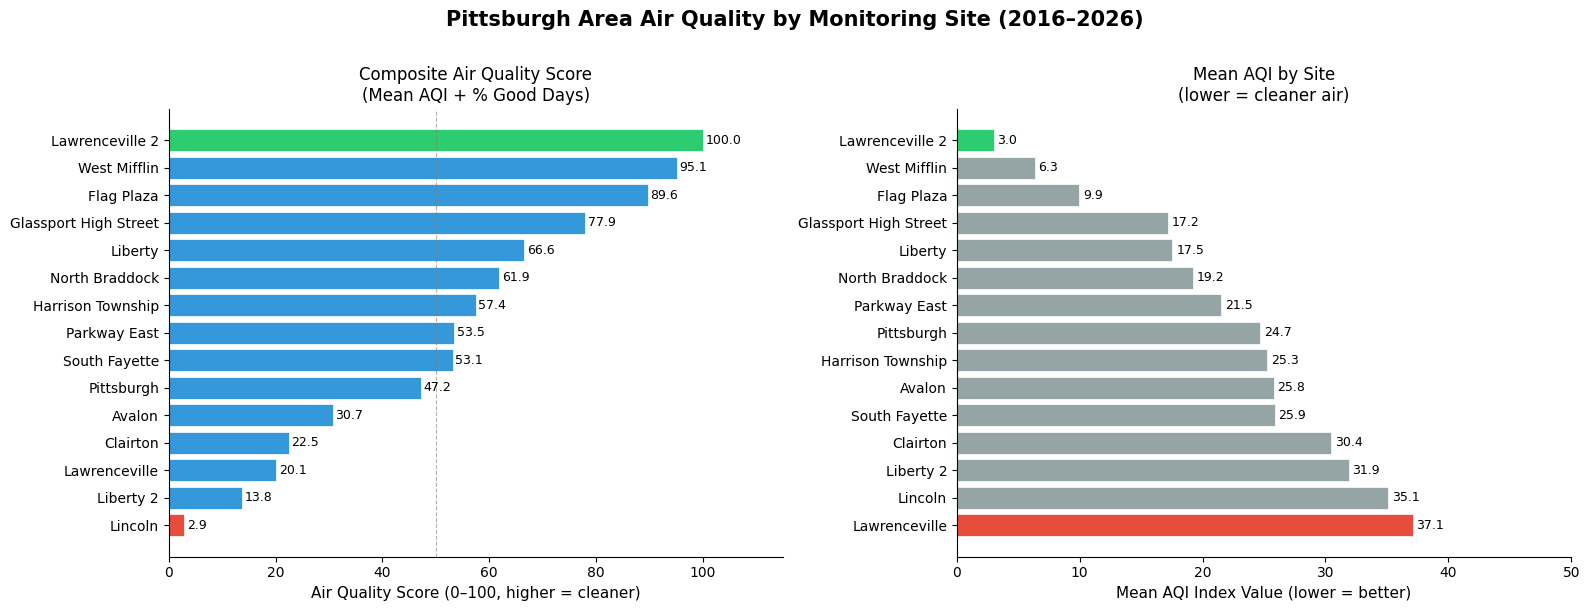

Chart saved as air_quality_ranking.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pittsburgh Area Air Quality by Monitoring Site (2016–2026)', fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Composite Air Quality Score
ax1 = axes[0]
colors = ['#2ecc71' if i == 0 else ('#e74c3c' if i == len(summary) - 1 else '#3498db')
          for i in range(len(summary))]
bars = ax1.barh(summary.index, summary['air_quality_score'], color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Air Quality Score (0–100, higher = cleaner)', fontsize=11)
ax1.set_title('Composite Air Quality Score\n(Mean AQI + % Good Days)', fontsize=12)
ax1.invert_yaxis()
ax1.axvline(x=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, summary['air_quality_score']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}', va='center', fontsize=9)
ax1.set_xlim(0, 115)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: Mean AQI by Site
ax2 = axes[1]
mean_sorted = summary['mean_aqi'].sort_values()
colors2 = ['#2ecc71' if i == 0 else ('#e74c3c' if i == len(mean_sorted) - 1 else '#95a5a6')
           for i in range(len(mean_sorted))]
bars2 = ax2.barh(mean_sorted.index, mean_sorted.values, color=colors2, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Mean AQI Index Value (lower = better)', fontsize=11)
ax2.set_title('Mean AQI by Site\n(lower = cleaner air)', fontsize=12)
ax2.invert_yaxis()
for bar, val in zip(bars2, mean_sorted.values):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}', va='center', fontsize=9)
ax2.set_xlim(0, 50)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('air_quality_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as air_quality_ranking.png")

### 3.5 Visualization — AQI Trend Over Time for Top & Bottom Sites

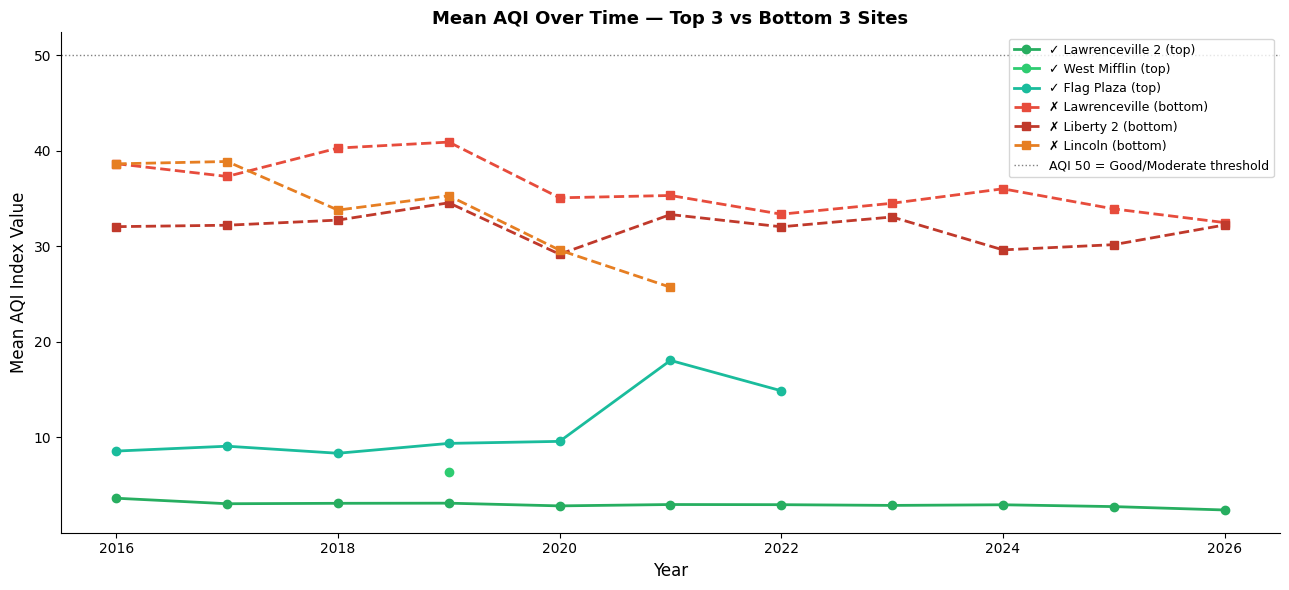

Trend chart saved as aqi_trend.png


In [9]:
# Pick the top 3 and bottom 3 sites by air quality score for trend comparison
top3 = summary.index[:3].tolist()
bottom3 = summary.index[-3:].tolist()
selected_sites = top3 + bottom3

df_trend = df[df['site'].isin(selected_sites)].copy()
df_trend['year'] = df_trend['date'].dt.year

yearly = df_trend.groupby(['year', 'site'])['index_value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

top_colors = ['#27ae60', '#2ecc71', '#1abc9c']
bot_colors = ['#e74c3c', '#c0392b', '#e67e22']

for site, color in zip(top3, top_colors):
    d = yearly[yearly['site'] == site]
    ax.plot(d['year'], d['index_value'], marker='o', color=color, linewidth=2, label=f'✓ {site} (top)')

for site, color in zip(bottom3, bot_colors):
    d = yearly[yearly['site'] == site]
    ax.plot(d['year'], d['index_value'], marker='s', linestyle='--', color=color, linewidth=2, label=f'✗ {site} (bottom)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean AQI Index Value', fontsize=12)
ax.set_title('Mean AQI Over Time — Top 3 vs Bottom 3 Sites', fontsize=13, fontweight='bold')
ax.axhline(y=50, color='gray', linestyle=':', linewidth=1, label='AQI 50 = Good/Moderate threshold')
ax.legend(loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Trend chart saved as aqi_trend.png")

### 3.6 Visualization — AQI Category Distribution by Site

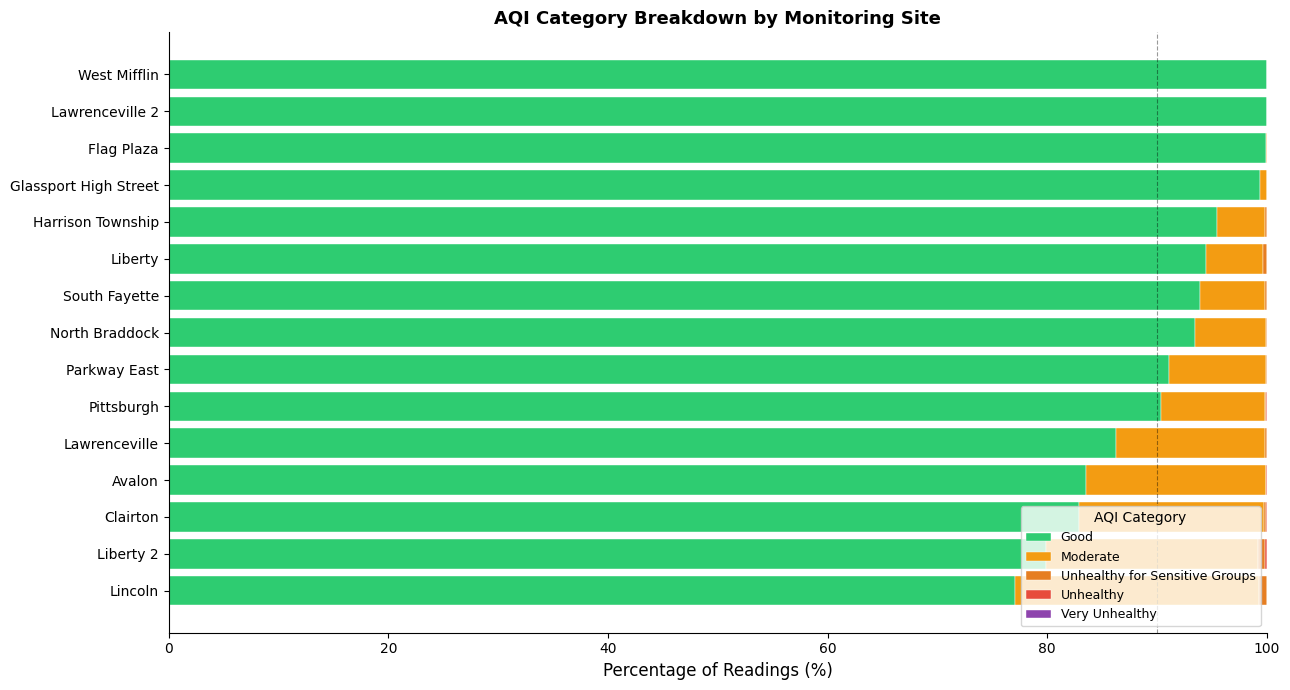

Category chart saved as aqi_categories.png


In [10]:
cat_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy']
cat_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']

# Compute proportion of each category per site
cat_counts = df.groupby(['site', 'description']).size().unstack(fill_value=0)
# Normalize to percentages
cat_pct = cat_counts.div(cat_counts.sum(axis=1), axis=0) * 100
# Reorder columns
cols_present = [c for c in cat_order if c in cat_pct.columns]
cat_pct = cat_pct[cols_present]
# Sort by % Good descending
cat_pct = cat_pct.sort_values('Good', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
left = np.zeros(len(cat_pct))
for col, color in zip(cols_present, cat_colors):
    vals = cat_pct[col].values
    ax.barh(cat_pct.index, vals, left=left, color=color, label=col, edgecolor='white', linewidth=0.3)
    left += vals

ax.set_xlabel('Percentage of Readings (%)', fontsize=12)
ax.set_title('AQI Category Breakdown by Monitoring Site', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, title='AQI Category')
ax.axvline(x=90, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('aqi_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Category chart saved as aqi_categories.png")

## 4. The Best Neighborhood — Air Quality Sub-Metric Result

In [11]:
winner = summary.index[0]
winner_score = summary.loc[winner, 'air_quality_score']
winner_mean_aqi = summary.loc[winner, 'mean_aqi']
winner_pct_good = summary.loc[winner, 'pct_good']

worst = summary.index[-1]
worst_mean_aqi = summary.loc[worst, 'mean_aqi']

print("=" * 55)
print(f"  🏆 BEST SITE (Air Quality): {winner}")
print(f"     Air Quality Score : {winner_score:.1f} / 100")
print(f"     Mean AQI          : {winner_mean_aqi:.2f}")
print(f"     % Good Readings   : {winner_pct_good:.1f}%")
print("=" * 55)
print()
print(f"  ❌ WORST SITE (Air Quality): {worst}")
print(f"     Mean AQI: {worst_mean_aqi:.2f}  (vs {winner_mean_aqi:.2f} for {winner})")
print("=" * 55)

  🏆 BEST SITE (Air Quality): Lawrenceville 2
     Air Quality Score : 100.0 / 100
     Mean AQI          : 3.00
     % Good Readings   : 100.0%

  ❌ WORST SITE (Air Quality): Lincoln
     Mean AQI: 35.11  (vs 3.00 for Lawrenceville 2)


### Narrative: Why This Site Wins on Air Quality

Based on a decade of AQI data collected by Allegheny County's air monitoring network, Lawrenceville 2 (and West Mifflin as a close second) consistently recorded the cleanest air in the Pittsburgh area. Both sites achieved a 100% "Good" reading rate across all measurements from 2016 to 2026, with mean AQI values of just 3.0 and 6.3 respectively, far below the 50-point "Good" threshold.

By contrast, sites in the Mon Valley industrial corridor particularly Lawrenceville (the primary station), Lincoln, and Liberty 2 recorded significantly higher average AQI values and were responsible for nearly all readings in the "Unhealthy for Sensitive Groups" or worse categories. Liberty 2 alone had 61 unhealthy readings over the dataset's timeframe, a reflection of its proximity to heavy industrial activity along the Monongahela River.

The trend chart further reveals that air quality has remained relatively stable or improved modestly at clean sites over the decade, while sites near industrial activity continue to show elevated and more variable readings.

From a public health standpoint, the gap is meaningful. Breathing air with an average AQI of 3 (Lawrenceville 2) vs. 37 (Lawrenceville primary station) over years of daily exposure represents a significant difference in long-term health risk. For this sub-metric, Lawrenceville 2 is the clear winner.

---

> **Note on data interpretation:** The monitoring stations in this dataset represent geographic areas, not always specific Pittsburgh neighborhoods by name. Sites like "Lawrenceville," "Liberty," and "Lincoln" correspond to monitoring equipment placed in or near those areas. "Lawrenceville 2" and "West Mifflin" represent additional monitoring points that happened to record the cleanest air in the dataset.

---

## 5. Sub-Metric Score (for Group Combination)


In [12]:
final_scores = summary[['mean_aqi', 'pct_good', 'unhealthy_count', 'air_quality_score']].copy()
final_scores.columns = ['Mean AQI', '% Good Readings', 'Unhealthy Reading Count', 'Air Quality Score (0–100)']
final_scores = final_scores.sort_values('Air Quality Score (0–100)', ascending=False)
final_scores.round(2)

,Mean AQI,% Good Readings,Unhealthy Reading Count,Air Quality Score (0–100)
site,,,,
Lawrenceville 2,3.00,100.00,0,100.00
West Mifflin,6.34,100.00,0,95.10
Flag Plaza,9.95,99.93,0,89.64
Glassport High Street,17.20,99.41,0,77.89
Liberty,17.55,94.46,13,66.59
North Braddock,19.22,93.44,12,61.90
Harrison Township,25.28,95.47,13,57.44
Parkway East,21.52,91.11,8,53.47
South Fayette,25.88,93.89,12,53.13


---

## 6. Conclusion

Going into this project, I expected air quality to vary across Pittsburgh, but I was surprised by just how stark the differences are. The Mon Valley industrial corridor shows AQI readings that are, on average, more than ten times higher than the cleanest sites in the dataset. Pittsburgh's industrial legacy isn't just history — it's still measurable in the air today.

This data-driven result partially aligns with my personal intuition: I'd heard that areas near the steel mills historically had worse air, so it wasn't shocking to see Liberty and Lincoln near the bottom. What I didn't expect was how well Lawrenceville 2 and West Mifflin would perform — those aren't places I would have immediately thought of as "clean air" neighborhoods.

If I were personally choosing a neighborhood based solely on air quality, the data would point me firmly away from the Mon Valley sites and toward the cleaner northern and western monitoring areas. That said, air quality is just one dimension of neighborhood quality. A place with pristine air but no amenities, poor transit, or high crime wouldn't be "best" by any holistic measure — which is exactly why our group is combining multiple sub-metrics for the final answer.

---

*Dataset source: Allegheny County Air Quality — WPRDC (https://data.wprdc.org)*